<a href="https://colab.research.google.com/github/atortosalopez/mineria-datos-turismo/blob/main/Trabajo_final_Mineria_datos_turismo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de sentimiento y minería de opiniones turísticas en reseñas de TripAdvisor en español

## Trabajo final de la asignatura Minería de datos y análisis de sentimiento: usos y aplicaciones en el sector turístico

Este trabajo tiene como objetivo aplicar técnicas básicas de minería de texto y análisis de sentimiento a un conjunto de reseñas turísticas en español. Para ello, se utilizarán datos procedentes de reseñas de hoteles, restaurantes y museos, con el fin de comparar la percepción de los usuarios en distintos tipos de experiencias turísticas.

El análisis se desarrollará mediante Python en un Jupyter Notebook, combinando técnicas de limpieza textual, exploración de datos, análisis de frecuencias, visualización y análisis de sentimiento.

## Índice

1. Introducción  
2. Carga y exploración de datos  
3. Detección de idioma  
4. Limpieza y preprocesamiento textual  
5. Análisis descriptivo  
6. Análisis léxico  
7. Bigramas  
8. Nubes de palabras  
9. Análisis de sentimiento  
10. Conclusiones

## 1. Introducción

Las reseñas publicadas por usuarios en plataformas turísticas constituyen una fuente de información muy valiosa para analizar la percepción de los visitantes. Estos textos permiten identificar aspectos positivos y negativos de la experiencia turística, como la calidad del servicio, la limpieza, la ubicación, la comida, el precio o el interés cultural de una visita.

Desde la perspectiva de la minería de textos, estas opiniones pueden estudiarse mediante técnicas de procesamiento del lenguaje natural, análisis estadístico y visualización de datos. En este trabajo se parte de varios corpus de reseñas turísticas en español y se aplican procedimientos básicos de limpieza, análisis léxico y análisis de sentimiento.

El objetivo no es únicamente obtener gráficos o métricas, sino interpretar qué patrones lingüísticos y valorativos aparecen en las reseñas y cómo varían según el tipo de servicio turístico analizado.

## 2. Objetivos

Los objetivos principales de este trabajo son los siguientes:

1. Cargar y explorar diferentes conjuntos de reseñas turísticas en español.
2. Aplicar técnicas de limpieza y normalización textual mediante Python y expresiones regulares.
3. Analizar las características generales de las reseñas, como su longitud y distribución.
4. Identificar las palabras y expresiones más frecuentes en cada tipo de corpus.
5. Comparar reseñas de hoteles, restaurantes y museos.
6. Realizar un análisis básico de sentimiento para observar la polaridad de las opiniones.
7. Interpretar los resultados obtenidos desde una perspectiva turística y lingüística.

In [1]:
# Importamos las librerías principales que se utilizarán en el análisis

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from collections import Counter

En esta primera celda se importan las librerías necesarias para el análisis.

La librería `pandas` permite cargar y manipular datos en formato tabular. `numpy` se utiliza para operaciones numéricas básicas. La librería `re` permite trabajar con expresiones regulares, que resultan útiles para limpiar y normalizar texto. `matplotlib` se empleará para generar gráficos, y `Counter` servirá para calcular frecuencias de palabras.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving reviews_museos_es.csv to reviews_museos_es (1).csv
Saving tripadvisor_hoteles_es.csv to tripadvisor_hoteles_es (1).csv
Saving tripadvisor_restaurantes_es.csv to tripadvisor_restaurantes_es (1).csv


Esta celda permite subir al entorno de trabajo los archivos CSV que contienen las reseñas turísticas. En este caso, se utilizarán los datasets de hoteles, restaurantes y museos. El objetivo es trabajar con datos reales y comparables entre sí.

In [3]:
hoteles = pd.read_csv("tripadvisor_hoteles_es.csv", sep='\t')
restaurantes = pd.read_csv("tripadvisor_restaurantes_es.csv", sep='\t')
museos = pd.read_csv("reviews_museos_es.csv", sep='\t')

In [4]:
print("Hoteles")
display(hoteles.head())

print("Restaurantes")
display(restaurantes.head())

print("Museos")
display(museos.head())

Hoteles


,text,genre,eval_entity_type,name,province,source,url,date,score
0,La zona del hotel es bonita y está a un paseo ...,review,urban,Senator Granada Spa Hotel,GR,Tripadvisor,https://www.tripadvisor.es/Hotel_Review-g18744...,2017-5-2,4
1,Tuve la suerte de compartir con este hotel un ...,review,urban,Hotel Palacio de Ubeda,JA,Tripadvisor,https://www.tripadvisor.es/Hotel_Review-g58027...,2018-10-2,5
2,Llegamos después de un largo viaje en moto a d...,review,urban,OYO Hotel Boutique Reina Mora,GR,Tripadvisor,https://www.tripadvisor.es/Hotel_Review-g18744...,2017-2-2,5
3,Es la tercera vez que nos alojamos en este hot...,review,beach,Helios Costa Tropical,GR,Tripadvisor,https://www.tripadvisor.es/Hotel_Review-g60898...,2020-8-2,5
4,"Teniendo en cuenta el precio, el hotel cumple ...",review,urban,Zeus Hotel Malaga,MA,Tripadvisor,https://www.tripadvisor.es/Hotel_Review-g18743...,2019-9-2,4


Restaurantes


,text,genre,eval_entity_type,name,province,source,url,date,score
0,I met this restaurant this summer and I just l...,review,international,Rigodon,CA,Tripadvisor,https://www.tripadvisor.com/Restaurant_Review-...,2017-7-22,5
1,Had an amazing meal at El Viajero Del Merkao. ...,review,international,El Viajero Del Merkao,CA,Tripadvisor,https://www.tripadvisor.com/Restaurant_Review-...,2016-5-4,5
2,Four of us enjoyed a very pleasant meal here l...,review,spanish,La Tarantella,MA,Tripadvisor,https://www.tripadvisor.com/Restaurant_Review-...,2017-10-10,3
3,Jaipur Purple always serves very good food. La...,review,indian,Jaipur Purple,MA,Tripadvisor,https://www.tripadvisor.com/Restaurant_Review-...,2013-7-25,4
4,"Today i went with my mom and dog to "" La Piká ...",review,latinoamerican,La Pika,AL,Tripadvisor,https://www.tripadvisor.com/Restaurant_Review-...,2018-5-14,5


Museos


,text,Museo,Estrellas,Fecha de la visita,Fecha de la opinión,Enlace
0,Hijo renombrado de Malaga. Ver cómo tuvo sus d...,Museo Picasso,4,Feb-20,Mar-20,https://www.tripadvisor.es/ShowUserReviews-g18...
1,Lugar encantador. Muy bien equipado con la vid...,Museo Picasso,5,Apr-19,Mar-20,https://www.tripadvisor.es/ShowUserReviews-g18...
2,Me esperaba más. No son obras de Picasso muy r...,Museo Picasso,3,Feb-20,Mar-20,https://www.tripadvisor.es/ShowUserReviews-g18...
3,Vista obligada en Málaga. Una de las mejores s...,Museo Picasso,5,Dec-19,Mar-20,https://www.tripadvisor.es/ShowUserReviews-g18...
4,Solo para amantes de la pintura. Vale 9 euros ...,Museo Picasso,2,Feb-20,Feb-20,https://www.tripadvisor.es/ShowUserReviews-g18...


Antes de iniciar el análisis, es necesario observar la estructura de los datos. La función `head()` permite visualizar las primeras filas de cada dataset y comprobar qué columnas contiene cada archivo. Este paso es importante para identificar la columna que contiene el texto de las reseñas y posibles variables adicionales, como puntuaciones, fechas o nombres de establecimientos.

In [5]:
print("Información del dataset de hoteles:")
hoteles.info()

print("\nInformación del dataset de restaurantes:")
restaurantes.info()

print("\nInformación del dataset de museos:")
museos.info()

Información del dataset de hoteles:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   text              100 non-null    object
 1   genre             100 non-null    object
 2   eval_entity_type  100 non-null    object
 3   name              100 non-null    object
 4   province          100 non-null    object
 5   source            100 non-null    object
 6   url               100 non-null    object
 7   date              100 non-null    object
 8   score             100 non-null    int64 
dtypes: int64(1), object(8)
memory usage: 7.2+ KB

Información del dataset de restaurantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   text              100 non-null    object
 1   genre            

Con `info()` se revisa el número de filas, columnas, tipos de datos y valores nulos de cada dataset. Esta información es fundamental para decidir si es necesario eliminar valores vacíos, transformar columnas o adaptar el análisis a la estructura concreta de los datos.

In [6]:
print("Número de reseñas de hoteles:", len(hoteles))
print("Número de reseñas de restaurantes:", len(restaurantes))
print("Número de reseñas de museos:", len(museos))

Número de reseñas de hoteles: 100
Número de reseñas de restaurantes: 100
Número de reseñas de museos: 150


En esta celda se calcula el número total de reseñas disponibles en cada corpus. Este dato permite conocer el tamaño de cada muestra y valorar si los tres conjuntos son comparables o si alguno de ellos tiene un volumen de datos mucho mayor que los demás.

In [7]:
print("Columnas hoteles:", hoteles.columns.tolist())
print("Columnas restaurantes:", restaurantes.columns.tolist())
print("Columnas museos:", museos.columns.tolist())

Columnas hoteles: ['text', 'genre', 'eval_entity_type', 'name', 'province', 'source', 'url', 'date', 'score']
Columnas restaurantes: ['text', 'genre', 'eval_entity_type', 'name', 'province', 'source', 'url', 'date', 'score']
Columnas museos: ['text', 'Museo', 'Estrellas', 'Fecha de la visita', 'Fecha de la opinión', 'Enlace']


Esta celda muestra el nombre de las columnas de cada dataset. El objetivo es identificar la columna que contiene el texto de las reseñas, ya que será la variable principal para el análisis textual.

## 3. Exploración cualitativa inicial de las reseñas

Antes de realizar el preprocesamiento, resulta necesario inspeccionar manualmente algunas reseñas para identificar posibles problemas textuales. Este paso permite detectar elementos como errores ortográficos, signos de puntuación inconsistentes, caracteres especiales, repeticiones, etiquetas HTML o formatos no homogéneos.

Además, esta revisión preliminar permite observar diferencias estilísticas entre los distintos tipos de reseñas turísticas.

In [8]:
# Mostramos algunas reseñas de ejemplo

print("RESEÑAS HOTELES")
for i in range(3):
    print("\n", hoteles["text"].iloc[i])

print("\n" + "="*80)

print("\nRESEÑAS RESTAURANTES")
for i in range(3):
    print("\n", restaurantes["text"].iloc[i])

print("\n" + "="*80)

print("\nRESEÑAS MUSEOS")
for i in range(3):
    print("\n", museos["text"].iloc[i])

RESEÑAS HOTELES

 La zona del hotel es bonita y está a un paseo del centro de la ciudad. Con la reserva entraba una sesión de Spa, el cual es bastante grande. También cogimos el desayuno que aunque muy variado y abundante nos decepcionó un poco, algún producto cocinado no estaba recién hecho. El trato fue muy correcto y nos facilitaron toda la información que les pedimos.

 Tuve la suerte de compartir con este hotel un momento tan especial como mi boda . Habló en nombre mío y de mi pareja. El trato, la calidad de la atención y de la comida, la organización y la habitación fueron sublimes.Un momento tan estresante como el día de tu boda, esos preparativos previos, esa organización que tan difícil se hace....con ellos ha sido espectacularmente fácil todo.No merece la pena pagar 10 euros menos por cubierto en otro sitio. Si te fías de mi comentario, gástalos y descansa. Se ocupan de todo, te tranquilizan y te quitan presión. Volvería a casarme ahí una y mil veces. Quien esté dudando entre

La exploración manual permite identificar algunas características frecuentes en este tipo de corpus, como la presencia de lenguaje informal, estructuras expresivas, puntuación enfática o diferencias en la extensión de las reseñas.

También permite detectar posibles elementos que deberán tratarse durante la fase de limpieza y normalización textual.

In [9]:
# Comprobamos si existen valores nulos

print("Valores nulos hoteles:", hoteles["text"].isnull().sum())
print("Valores nulos restaurantes:", restaurantes["text"].isnull().sum())
print("Valores nulos museos:", museos["text"].isnull().sum())

Valores nulos hoteles: 0
Valores nulos restaurantes: 0
Valores nulos museos: 0


También se verifica la existencia de valores nulos en la columna textual. Este control es importante porque los valores vacíos pueden provocar errores durante determinadas operaciones de procesamiento lingüístico.

## 4. Filtrado lingüístico del corpus

Durante la exploración manual de las reseñas se observó la presencia de algunos textos escritos en inglés, especialmente en el corpus de restaurantes.

Dado que el objetivo del trabajo es analizar reseñas turísticas en español, se realizará un filtrado lingüístico básico para conservar únicamente los textos en español y garantizar una mayor coherencia en el análisis posterior.

In [10]:
!pip install langdetect

In [11]:
from langdetect import detect

In [12]:
# Función para detectar idioma

def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "unknown"

In [13]:
# Detectamos idioma de las reseñas

hoteles["language"] = hoteles["text"].apply(detectar_idioma)
restaurantes["language"] = restaurantes["text"].apply(detectar_idioma)
museos["language"] = museos["text"].apply(detectar_idioma)

In [14]:
print(hoteles["language"].value_counts())

print("\n" + "="*50)

print(restaurantes["language"].value_counts())

print("\n" + "="*50)

print(museos["language"].value_counts())

language
es    100
Name: count, dtype: int64

language
en    100
Name: count, dtype: int64

language
es    150
Name: count, dtype: int64


La detección automática de idioma permite identificar la presencia de textos escritos en lenguas distintas del español. Este paso es importante para evitar que el análisis léxico y el análisis de sentimiento se vean afectados por la mezcla de idiomas dentro del corpus.

In [15]:
# Conservamos todos los corpus
# Se observa que el corpus de restaurantes contiene principalmente reseñas en inglés

print(hoteles["language"].value_counts())

print("\n" + "="*50)

print(restaurantes["language"].value_counts())

print("\n" + "="*50)

print(museos["language"].value_counts())

language
es    100
Name: count, dtype: int64

language
en    100
Name: count, dtype: int64

language
es    150
Name: count, dtype: int64


La detección de idioma muestra una distribución lingüística claramente diferenciada entre los corpus. Mientras que las reseñas de hoteles y museos están escritas principalmente en español, el corpus de restaurantes contiene mayoritariamente textos en inglés.

Esta diferencia se conservará en el análisis con fines comparativos y se tendrá en cuenta durante la interpretación de los resultados.

# 5. Limpieza y preprocesamiento textual

El preprocesamiento constituye una fase fundamental dentro de cualquier proyecto de minería de texto. Los corpus reales suelen contener inconsistencias ortográficas, espacios innecesarios, signos de puntuación irregulares o elementos que dificultan el análisis automático.

En esta fase se aplicarán diferentes técnicas de limpieza y normalización utilizando Python y expresiones regulares. El objetivo es obtener versiones más homogéneas de las reseñas sin alterar su contenido semántico principal.

In [16]:
# Creamos copias de trabajo de los datasets

hoteles_clean = hoteles.copy()
restaurantes_clean = restaurantes.copy()
museos_clean = museos.copy()

Antes de iniciar el preprocesamiento, se crean copias independientes de los datasets originales. De este modo, los datos originales permanecen intactos y todas las transformaciones se realizan sobre nuevas versiones de trabajo.

In [17]:
# Convertimos el texto a minúsculas

hoteles_clean["clean_text"] = hoteles_clean["text"].str.lower()
restaurantes_clean["clean_text"] = restaurantes_clean["text"].str.lower()
museos_clean["clean_text"] = museos_clean["text"].str.lower()

La conversión a minúsculas permite evitar duplicidades léxicas durante el análisis. Por ejemplo, las palabras “Hotel” y “hotel” pasarán a considerarse la misma unidad textual.

In [18]:
# Eliminamos espacios innecesarios

hoteles_clean["clean_text"] = hoteles_clean["clean_text"].str.strip()
restaurantes_clean["clean_text"] = restaurantes_clean["clean_text"].str.strip()
museos_clean["clean_text"] = museos_clean["clean_text"].str.strip()

In [19]:
# Eliminamos URLs mediante expresiones regulares

pattern_url = r"http\S+|www\S+"

hoteles_clean["clean_text"] = hoteles_clean["clean_text"].str.replace(pattern_url, "", regex=True)
restaurantes_clean["clean_text"] = restaurantes_clean["clean_text"].str.replace(pattern_url, "", regex=True)
museos_clean["clean_text"] = museos_clean["clean_text"].str.replace(pattern_url, "", regex=True)

También se eliminan posibles direcciones web o URLs mediante expresiones regulares. Estos elementos no aportan información relevante para el análisis lingüístico y pueden introducir ruido en los resultados.

In [20]:
# Reducimos caracteres repetidos exagerados

def reducir_repeticiones(texto):
    return re.sub(r'(.)\1{2,}', r'\1\1', texto)

hoteles_clean["clean_text"] = hoteles_clean["clean_text"].apply(reducir_repeticiones)
restaurantes_clean["clean_text"] = restaurantes_clean["clean_text"].apply(reducir_repeticiones)
museos_clean["clean_text"] = museos_clean["clean_text"].apply(reducir_repeticiones)

En las reseñas online aparecen frecuentemente secuencias de caracteres repetidos con finalidad expresiva, como “buenoooo” o “geniaaaal”. Mediante expresiones regulares se reducen estas repeticiones excesivas para homogeneizar el corpus sin eliminar completamente la carga expresiva del texto.

In [21]:
# Eliminamos parte de la puntuación
# Conservamos exclamaciones e interrogaciones por su posible valor emocional

pattern_puntuacion = r"[\"#$%&'()*+,\-/:;<=>@[\\]^_`{|}~]"

hoteles_clean["clean_text"] = hoteles_clean["clean_text"].str.replace(pattern_puntuacion, " ", regex=True)
restaurantes_clean["clean_text"] = restaurantes_clean["clean_text"].str.replace(pattern_puntuacion, " ", regex=True)
museos_clean["clean_text"] = museos_clean["clean_text"].str.replace(pattern_puntuacion, " ", regex=True)

No toda la puntuación posee el mismo valor lingüístico. En este trabajo se eliminan signos secundarios, pero se conservan exclamaciones e interrogaciones debido a su posible función expresiva dentro de las reseñas.

In [22]:
# Eliminamos espacios múltiples

hoteles_clean["clean_text"] = hoteles_clean["clean_text"].str.replace(r"\s+", " ", regex=True)
restaurantes_clean["clean_text"] = restaurantes_clean["clean_text"].str.replace(r"\s+", " ", regex=True)
museos_clean["clean_text"] = museos_clean["clean_text"].str.replace(r"\s+", " ", regex=True)

In [23]:
# Comparación entre texto original y texto limpio

print("TEXTO ORIGINAL:\n")
print(hoteles["text"].iloc[0])

print("\n" + "="*80)

print("\nTEXTO LIMPIO:\n")
print(hoteles_clean["clean_text"].iloc[0])

TEXTO ORIGINAL:

La zona del hotel es bonita y está a un paseo del centro de la ciudad. Con la reserva entraba una sesión de Spa, el cual es bastante grande. También cogimos el desayuno que aunque muy variado y abundante nos decepcionó un poco, algún producto cocinado no estaba recién hecho. El trato fue muy correcto y nos facilitaron toda la información que les pedimos.


TEXTO LIMPIO:

la zona del hotel es bonita y está a un paseo del centro de la ciudad. con la reserva entraba una sesión de spa, el cual es bastante grande. también cogimos el desayuno que aunque muy variado y abundante nos decepcionó un poco, algún producto cocinado no estaba recién hecho. el trato fue muy correcto y nos facilitaron toda la información que les pedimos.


La comparación entre el texto original y la versión preprocesada permite observar las transformaciones realizadas durante la limpieza textual y comprobar que el contenido principal de las reseñas se mantiene intacto.

# 6. Análisis descriptivo del corpus

Una vez realizado el preprocesamiento, se procede a realizar un análisis descriptivo de los corpus. El objetivo es explorar algunas características generales de las reseñas, como su longitud, distribución y diferencias entre tipos de experiencias turísticas.

Este tipo de análisis permite identificar patrones básicos antes de aplicar técnicas más avanzadas de minería textual y análisis de sentimiento.

In [24]:
# Calculamos la longitud de las reseñas en número de palabras

hoteles_clean["word_count"] = hoteles_clean["clean_text"].apply(lambda x: len(x.split()))
restaurantes_clean["word_count"] = restaurantes_clean["clean_text"].apply(lambda x: len(x.split()))
museos_clean["word_count"] = museos_clean["clean_text"].apply(lambda x: len(x.split()))

En esta fase se calcula la longitud de cada reseña en número de palabras. Esta variable permite comparar el grado de detalle y extensión de las opiniones publicadas por los usuarios en los distintos corpus turísticos.

In [25]:
print("MEDIA DE PALABRAS POR RESEÑA\n")

print("Hoteles:", round(hoteles_clean["word_count"].mean(), 2))
print("Restaurantes:", round(restaurantes_clean["word_count"].mean(), 2))
print("Museos:", round(museos_clean["word_count"].mean(), 2))

MEDIA DE PALABRAS POR RESEÑA

Hoteles: 96.08
Restaurantes: 98.72
Museos: 62.29


La media de palabras por reseña permite observar diferencias en la extensión de los comentarios según el tipo de experiencia turística. Las reseñas más largas suelen contener descripciones más detalladas, mientras que las más breves tienden a ser evaluaciones más directas.

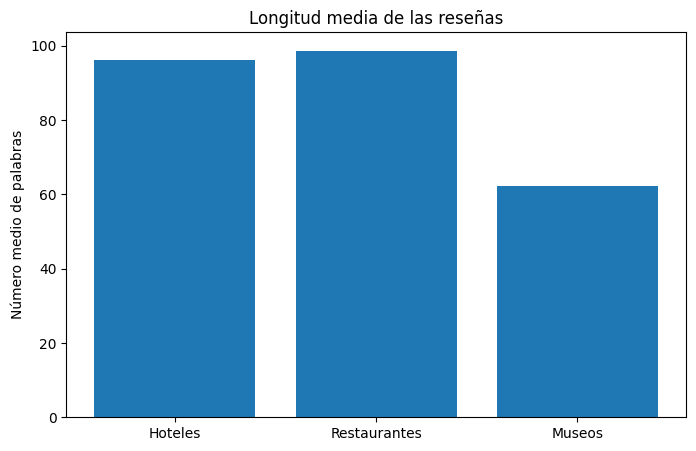

In [26]:
# Gráfico comparativo de longitud media

categorias = ["Hoteles", "Restaurantes", "Museos"]

medias = [
    hoteles_clean["word_count"].mean(),
    restaurantes_clean["word_count"].mean(),
    museos_clean["word_count"].mean()
]

plt.figure(figsize=(8,5))

plt.bar(categorias, medias)

plt.ylabel("Número medio de palabras")
plt.title("Longitud media de las reseñas")

plt.show()

El gráfico permite comparar visualmente la longitud media de las reseñas en los distintos corpus. Estas diferencias pueden reflejar distintos estilos discursivos y diferentes formas de evaluar la experiencia turística.

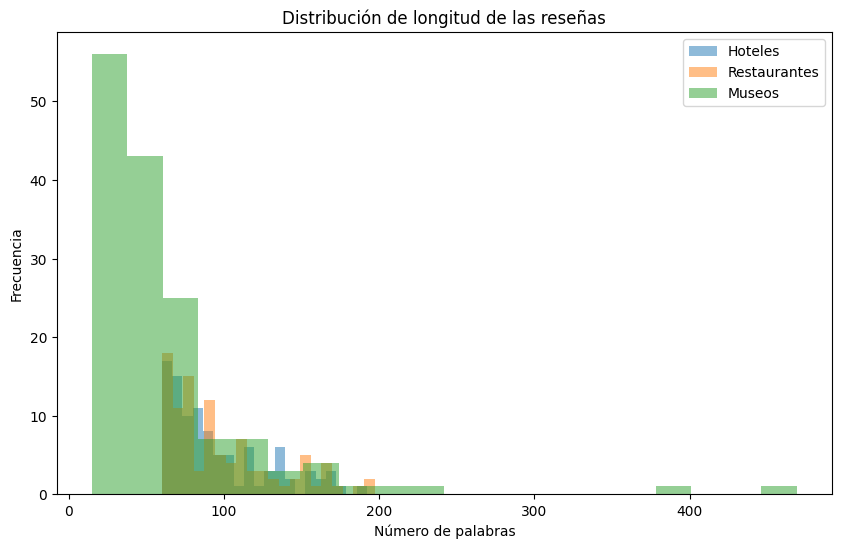

In [27]:
# Distribución de longitud de reseñas

plt.figure(figsize=(10,6))

plt.hist(hoteles_clean["word_count"], bins=20, alpha=0.5, label="Hoteles")
plt.hist(restaurantes_clean["word_count"], bins=20, alpha=0.5, label="Restaurantes")
plt.hist(museos_clean["word_count"], bins=20, alpha=0.5, label="Museos")

plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.title("Distribución de longitud de las reseñas")

plt.legend()

plt.show()

La distribución de frecuencias permite observar no solo la media, sino también la variabilidad en la longitud de las reseñas. Algunos corpus presentan comentarios más homogéneos, mientras que otros muestran una mayor dispersión en el tamaño de los textos.

Los resultados muestran diferencias relevantes entre los distintos corpus turísticos. Las reseñas de restaurantes presentan, en promedio, una mayor longitud, lo que puede relacionarse con un estilo discursivo más narrativo y experiencial. Los usuarios suelen describir aspectos como la comida, el servicio, el ambiente o la relación calidad-precio con bastante detalle.

Por el contrario, las reseñas de museos tienden a ser más breves y directas, aunque el histograma revela también la existencia de algunos comentarios excepcionalmente extensos. Esto sugiere la coexistencia de dos patrones discursivos diferentes: evaluaciones rápidas y descripciones culturales más elaboradas.

Las reseñas hoteleras presentan un comportamiento intermedio entre ambos corpus.

# 7. Análisis léxico del corpus

El análisis léxico permite identificar las palabras más frecuentes dentro de cada corpus y observar qué conceptos aparecen con mayor relevancia en las reseñas.

Este tipo de análisis resulta útil para detectar temas recurrentes, preferencias de los usuarios y diferencias discursivas entre distintos tipos de experiencias turísticas.

In [28]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
from nltk.corpus import stopwords

In [30]:
stopwords_es = set(stopwords.words('spanish'))
stopwords_en = set(stopwords.words('english'))

In [31]:
# Función para tokenizar y limpiar palabras

def obtener_palabras(textos, stopwords_set):

    palabras = []

    for texto in textos:

        tokens = texto.split()

        tokens_limpios = [
            palabra for palabra in tokens
            if palabra.isalpha() and palabra not in stopwords_set
        ]

        palabras.extend(tokens_limpios)

    return palabras

In [32]:
# Hoteles (español)

palabras_hoteles = obtener_palabras(
    hoteles_clean["clean_text"],
    stopwords_es
)

# Restaurantes (inglés)

palabras_restaurantes = obtener_palabras(
    restaurantes_clean["clean_text"],
    stopwords_en
)

# Museos (español)

palabras_museos = obtener_palabras(
    museos_clean["clean_text"],
    stopwords_es
)

In [33]:
freq_hoteles = Counter(palabras_hoteles)
freq_restaurantes = Counter(palabras_restaurantes)
freq_museos = Counter(palabras_museos)

In [34]:
print("PALABRAS MÁS FRECUENTES - HOTELES\n")
print(freq_hoteles.most_common(15))

print("\n" + "="*70)

print("\nPALABRAS MÁS FRECUENTES - RESTAURANTES\n")
print(freq_restaurantes.most_common(15))

print("\n" + "="*70)

print("\nPALABRAS MÁS FRECUENTES - MUSEOS\n")
print(freq_museos.most_common(15))

PALABRAS MÁS FRECUENTES - HOTELES

[('hotel', 111), ('personal', 49), ('habitación', 46), ('habitaciones', 35), ('desayuno', 30), ('bien', 30), ('si', 27), ('buena', 24), ('comida', 21), ('vistas', 20), ('buen', 20), ('aunque', 19), ('trato', 19), ('tan', 18), ('semana', 17)]


PALABRAS MÁS FRECUENTES - RESTAURANTES

[('food', 63), ('restaurant', 43), ('good', 39), ('service', 35), ('great', 29), ('menu', 28), ('place', 27), ('would', 26), ('well', 25), ('one', 24), ('wine', 23), ('staff', 23), ('us', 22), ('really', 21), ('quality', 21)]


PALABRAS MÁS FRECUENTES - MUSEOS

[('museo', 112), ('visita', 39), ('gran', 36), ('si', 35), ('colección', 34), ('málaga', 33), ('obras', 32), ('ver', 28), ('edificio', 27), ('exposición', 27), ('interesante', 23), ('arte', 23), ('bien', 19), ('exposiciones', 19), ('entrada', 18)]


La extracción de palabras frecuentes permite identificar algunos de los conceptos más recurrentes en las reseñas. Para ello, se eliminan previamente las llamadas *stopwords* o palabras vacías, es decir, términos gramaticales muy frecuentes que aportan poca información semántica.

Dado que el corpus de restaurantes está escrito principalmente en inglés, se utilizan listas de stopwords diferentes según el idioma del corpus.

Los resultados muestran diferencias léxicas claras entre los distintos tipos de corpus turísticos.

En las reseñas hoteleras predominan términos relacionados con la atención al cliente, las habitaciones y los servicios del alojamiento, como “personal”, “habitación”, “desayuno” o “trato”. Esto refleja un enfoque centrado en la comodidad y la calidad del servicio.

En el corpus de restaurantes destacan palabras vinculadas a la experiencia gastronómica, como “food”, “menu”, “wine” o “service”. Además, aparecen numerosos términos valorativos en inglés, como “good” o “great”, lo que sugiere un discurso altamente evaluativo y emocional.

Por su parte, las reseñas de museos presentan un vocabulario claramente cultural y patrimonial, con términos como “colección”, “arte”, “obras” o “exposición”. Esto indica un estilo más descriptivo y orientado al contenido artístico de la experiencia.

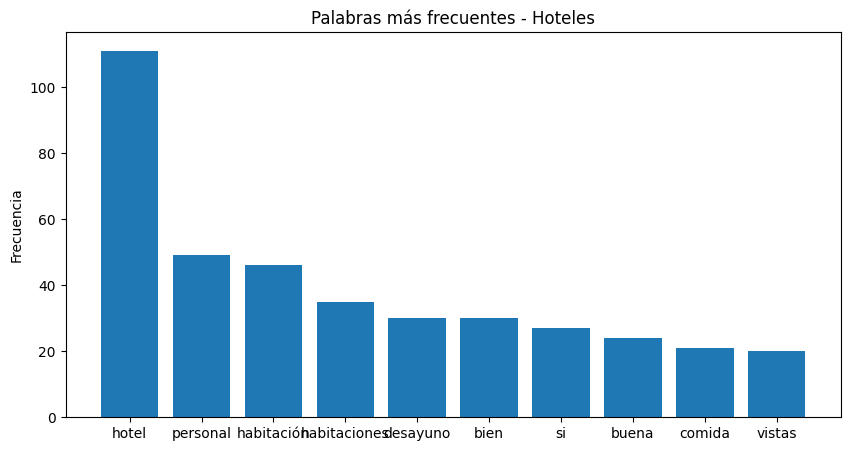

In [35]:
# Top 10 palabras hoteles

top_hoteles = freq_hoteles.most_common(10)

palabras = [x[0] for x in top_hoteles]
frecuencias = [x[1] for x in top_hoteles]

plt.figure(figsize=(10,5))

plt.bar(palabras, frecuencias)

plt.title("Palabras más frecuentes - Hoteles")
plt.ylabel("Frecuencia")

plt.show()

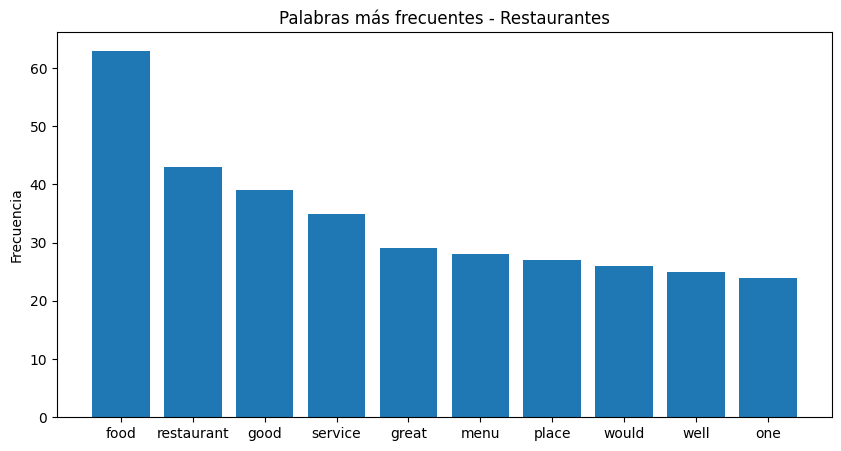

In [36]:
# Top 10 palabras restaurantes

top_restaurantes = freq_restaurantes.most_common(10)

palabras = [x[0] for x in top_restaurantes]
frecuencias = [x[1] for x in top_restaurantes]

plt.figure(figsize=(10,5))

plt.bar(palabras, frecuencias)

plt.title("Palabras más frecuentes - Restaurantes")
plt.ylabel("Frecuencia")

plt.show()

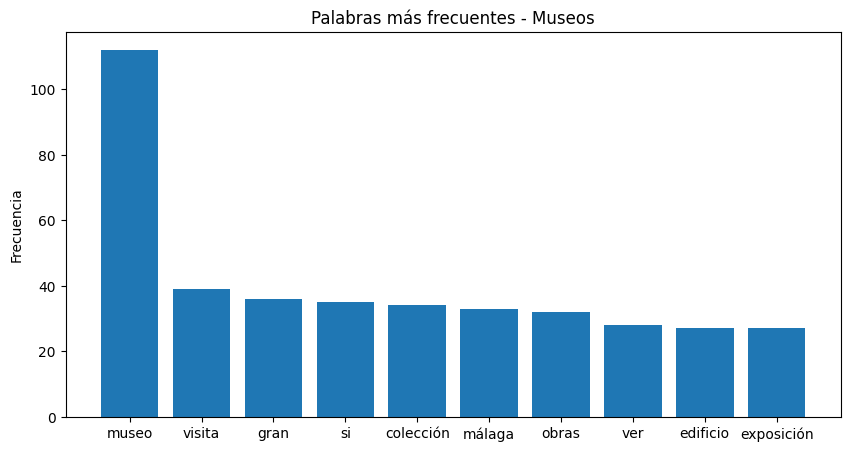

In [37]:
# Top 10 palabras museos

top_museos = freq_museos.most_common(10)

palabras = [x[0] for x in top_museos]
frecuencias = [x[1] for x in top_museos]

plt.figure(figsize=(10,5))

plt.bar(palabras, frecuencias)

plt.title("Palabras más frecuentes - Museos")
plt.ylabel("Frecuencia")

plt.show()

La visualización de palabras frecuentes permite observar de forma más intuitiva los conceptos predominantes en cada corpus turístico. Los gráficos muestran diferencias temáticas claras entre alojamiento, gastronomía y turismo cultural.

Los gráficos muestran no solo diferencias temáticas entre los corpus, sino también diferencias en el tipo de lenguaje utilizado por los usuarios.

En las reseñas hoteleras y gastronómicas aparecen numerosos términos valorativos, como “bien”, “buena”, “good” o “great”, lo que refleja una fuerte dimensión evaluativa y emocional. Por el contrario, el corpus de museos contiene un vocabulario más descriptivo y cultural, relacionado con elementos patrimoniales y artísticos.

Esto sugiere que cada tipo de experiencia turística genera patrones discursivos diferentes.

# 8. Análisis de bigramas

Además de las palabras individuales, resulta útil analizar secuencias frecuentes de dos palabras consecutivas, conocidas como *bigramas*.

Los bigramas permiten identificar expresiones habituales dentro de las reseñas y proporcionan un contexto semántico más rico que las palabras aisladas.

In [38]:
from nltk.util import bigrams

In [39]:
# Función para obtener bigramas

def obtener_bigramas(lista_palabras):

    return list(bigrams(lista_palabras))

In [40]:
bigramas_hoteles = obtener_bigramas(palabras_hoteles)
bigramas_restaurantes = obtener_bigramas(palabras_restaurantes)
bigramas_museos = obtener_bigramas(palabras_museos)

In [41]:
freq_bigramas_hoteles = Counter(bigramas_hoteles)
freq_bigramas_restaurantes = Counter(bigramas_restaurantes)
freq_bigramas_museos = Counter(bigramas_museos)

In [42]:
print("BIGRAMAS MÁS FRECUENTES - HOTELES\n")
print(freq_bigramas_hoteles.most_common(10))

print("\n" + "="*70)

print("\nBIGRAMAS MÁS FRECUENTES - RESTAURANTES\n")
print(freq_bigramas_restaurantes.most_common(10))

print("\n" + "="*70)

print("\nBIGRAMAS MÁS FRECUENTES - MUSEOS\n")
print(freq_bigramas_museos.most_common(10))

BIGRAMAS MÁS FRECUENTES - HOTELES

[(('personal', 'amable'), 7), (('fin', 'semana'), 5), (('personal', 'recepción'), 5), (('habitación', 'vistas'), 5), (('bien', 'situado'), 4), (('aire', 'acondicionado'), 4), (('habitaciones', 'amplias'), 4), (('hotel', 'bonito'), 4), (('hotel', 'bien'), 4), (('hotel', 'habitaciones'), 4)]


BIGRAMAS MÁS FRECUENTES - RESTAURANTES

[(('well', 'worth'), 6), (('one', 'best'), 5), (('food', 'excellent'), 5), (('quality', 'food'), 5), (('many', 'restaurants'), 4), (('staff', 'friendly'), 4), (('highly', 'recommended'), 4), (('many', 'times'), 4), (('wine', 'list'), 3), (('main', 'course'), 3)]


BIGRAMAS MÁS FRECUENTES - MUSEOS

[(('merece', 'pena'), 6), (('gran', 'museo'), 6), (('museo', 'interesante'), 6), (('interesante', 'museo'), 5), (('vale', 'pena'), 5), (('visita', 'museo'), 4), (('colección', 'permanente'), 4), (('si', 'gusta'), 4), (('gran', 'variedad'), 4), (('exposiciones', 'temporales'), 3)]


El análisis de bigramas permite observar combinaciones léxicas frecuentes dentro de las reseñas. Estas expresiones ofrecen información más precisa sobre los aspectos que los usuarios valoran o describen en cada tipo de experiencia turística.

El análisis de bigramas permite identificar patrones fraseológicos característicos de cada tipo de experiencia turística.

En las reseñas hoteleras predominan expresiones relacionadas con el servicio y las instalaciones, como “personal amable”, “aire acondicionado” o “habitaciones amplias”. Esto refleja una preocupación por la comodidad y la calidad funcional del alojamiento.

En el corpus gastronómico aparecen numerosas expresiones valorativas y recomendativas, como “food excellent”, “staff friendly” o “highly recommended”. Este patrón sugiere un discurso más emocional y orientado a la evaluación subjetiva de la experiencia culinaria.

Por su parte, las reseñas de museos presentan combinaciones léxicas claramente vinculadas al ámbito cultural y patrimonial, como “colección permanente”, “exposiciones temporales” o “gran museo”. Estas expresiones muestran un enfoque más descriptivo y cultural.

In [43]:
!pip install wordcloud

In [44]:
from wordcloud import WordCloud

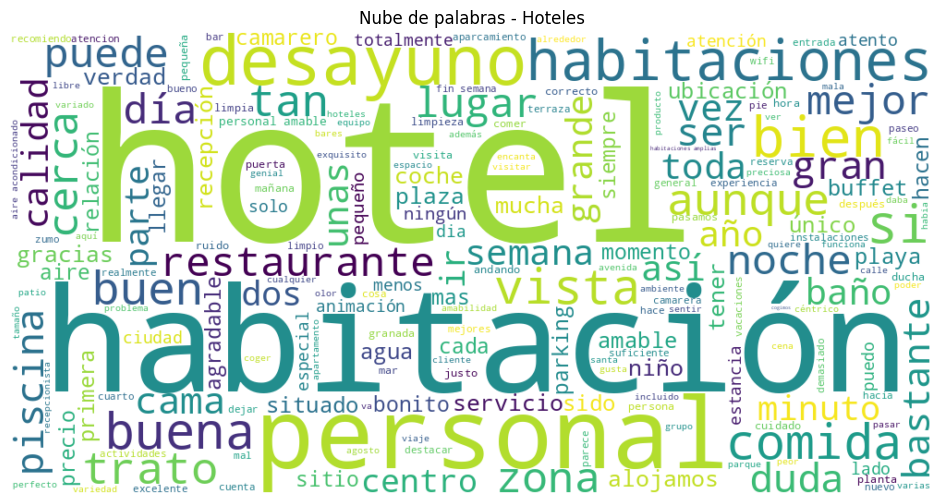

In [45]:
# Nube de palabras - Hoteles

texto_hoteles = " ".join(palabras_hoteles)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(texto_hoteles)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nube de palabras - Hoteles")

plt.show()

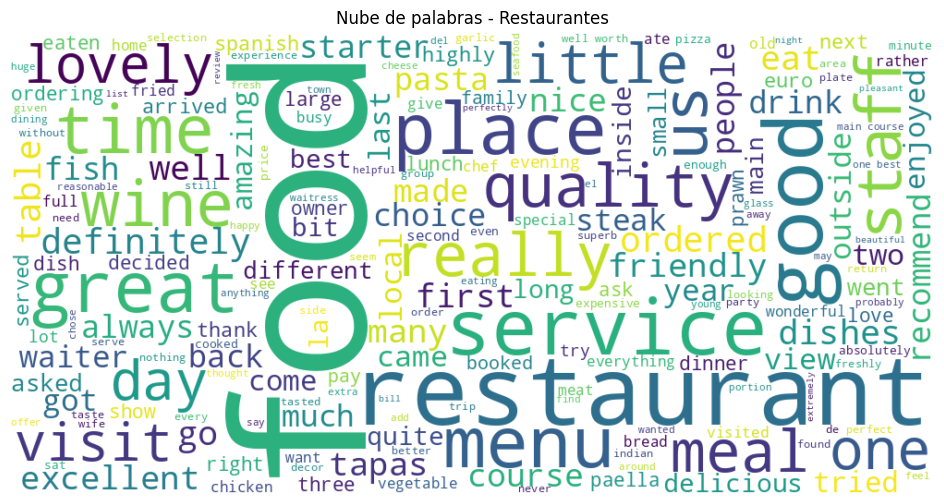

In [46]:
# Nube de palabras - Restaurantes

texto_restaurantes = " ".join(palabras_restaurantes)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(texto_restaurantes)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nube de palabras - Restaurantes")

plt.show()

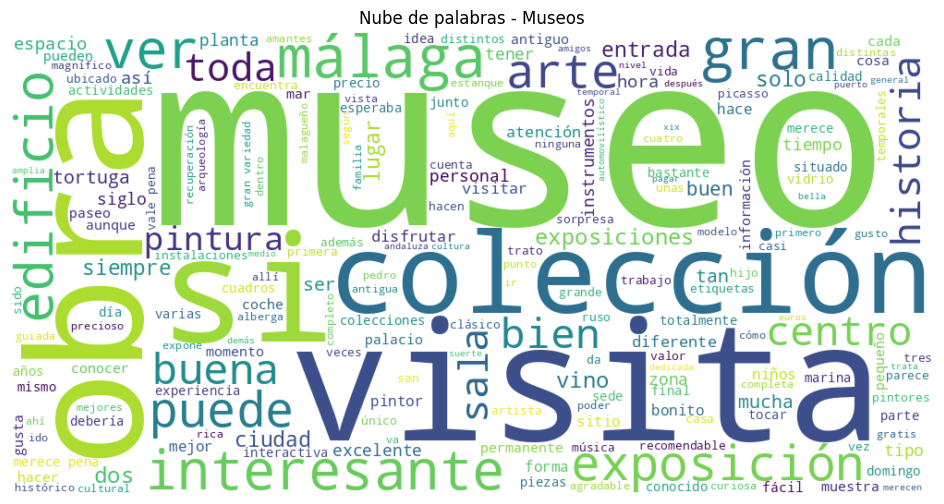

In [47]:
# Nube de palabras - Museos

texto_museos = " ".join(palabras_museos)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(texto_museos)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nube de palabras - Museos")

plt.show()

Las nubes de palabras permiten representar visualmente los términos más frecuentes de cada corpus. El tamaño de cada palabra está relacionado con su frecuencia de aparición dentro de las reseñas.

Este tipo de visualización facilita la identificación rápida de temas predominantes y patrones léxicos característicos de cada ámbito turístico.

Las nubes de palabras refuerzan los patrones observados previamente en el análisis léxico y de bigramas.

En el corpus hotelero predominan términos relacionados con las instalaciones, la atención al cliente y la comodidad del alojamiento, como “habitación”, “personal”, “desayuno” o “trato”. Esto sugiere una evaluación centrada en aspectos funcionales y de servicio.

Las reseñas gastronómicas muestran un lenguaje claramente evaluativo y emocional, con abundancia de términos como “good”, “great”, “excellent” o “lovely”. El foco principal se sitúa en la experiencia culinaria y en la valoración subjetiva del servicio y la comida.

Por el contrario, el corpus de museos presenta un vocabulario más cultural y patrimonial, con referencias frecuentes a “arte”, “colección”, “historia”, “exposición” o “edificio”. Esto indica un estilo discursivo más descriptivo y orientado al contenido cultural de la experiencia turística.

# 10. Análisis de sentimiento

El análisis de sentimiento permite estimar automáticamente la polaridad emocional de las reseñas. Este tipo de análisis resulta especialmente útil en el ámbito turístico, ya que permite detectar tendencias generales de satisfacción o insatisfacción de los usuarios.

En este trabajo se utilizará la librería TextBlob para calcular una puntuación aproximada de polaridad en cada reseña.

In [48]:
!pip install textblob

In [49]:
from textblob import TextBlob

In [50]:
# Función simple de polaridad para textos en inglés

def obtener_polaridad(texto):

    return TextBlob(texto).sentiment.polarity

In [51]:
# Calculamos polaridad únicamente para el corpus en inglés

restaurantes_clean["polarity"] = restaurantes_clean["clean_text"].apply(obtener_polaridad)

In [52]:
print("POLARIDAD MEDIA - RESTAURANTES\n")

print(
    round(restaurantes_clean["polarity"].mean(), 3)
)

POLARIDAD MEDIA - RESTAURANTES

0.267


La polaridad oscila entre -1 y 1. Los valores cercanos a 1 indican una valoración positiva, mientras que los valores negativos reflejan opiniones desfavorables.

El cálculo de la polaridad media permite comparar el tono general de las reseñas en los distintos corpus turísticos.

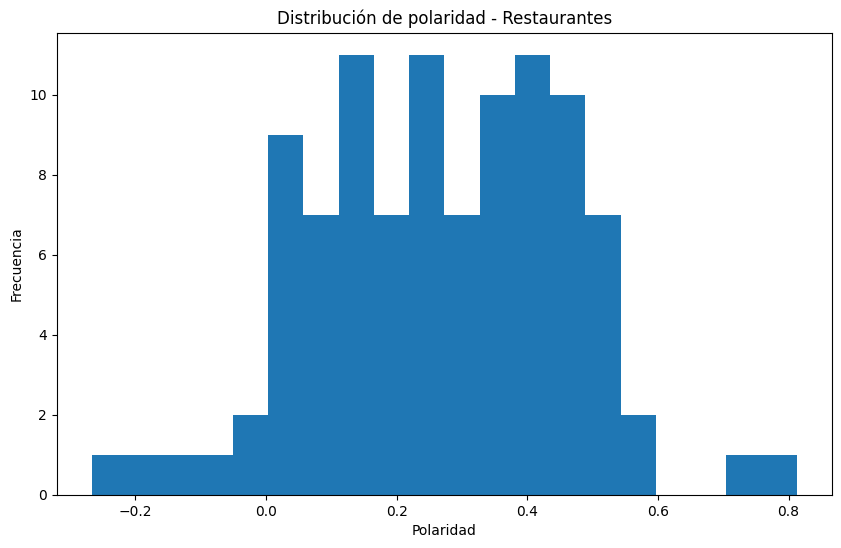

In [53]:
plt.figure(figsize=(10,6))

plt.hist(
    restaurantes_clean["polarity"],
    bins=20
)

plt.xlabel("Polaridad")
plt.ylabel("Frecuencia")

plt.title("Distribución de polaridad - Restaurantes")

plt.show()

El análisis de sentimiento se aplicó principalmente al corpus de restaurantes, ya que este conjunto de reseñas está escrito en inglés y resulta compatible con las herramientas de análisis de polaridad utilizadas en este trabajo.

Los resultados permiten estimar automáticamente el tono emocional de las opiniones y observar la predominancia de valoraciones positivas o negativas dentro del corpus gastronómico.

El histograma muestra una clara predominancia de valores positivos en las reseñas gastronómicas, lo que indica una tendencia general de satisfacción por parte de los usuarios.

La mayoría de las opiniones se concentran en polaridades moderadamente positivas, mientras que las valoraciones claramente negativas aparecen con menor frecuencia. Esto sugiere que el corpus contiene principalmente experiencias favorables, aunque existe también cierta diversidad valorativa.

La distribución observada resulta coherente con el lenguaje evaluativo identificado previamente en el análisis léxico y en los bigramas frecuentes.

# 9.1 Limitaciones metodológicas

Este trabajo presenta algunas limitaciones que deben tenerse en cuenta durante la interpretación de los resultados.

En primer lugar, los corpus utilizados presentan diferencias lingüísticas importantes, ya que las reseñas de restaurantes están escritas principalmente en inglés, mientras que los otros conjuntos de datos se encuentran en español. Esta situación condicionó algunas fases del análisis, especialmente el análisis de sentimiento.

Además, el tamaño de los datasets es relativamente reducido, por lo que las conclusiones obtenidas deben interpretarse como tendencias exploratorias y no como resultados plenamente generalizables.

Por otra parte, las técnicas utilizadas se basan principalmente en métodos léxicos y estadísticos sencillos. El uso de modelos más avanzados de procesamiento del lenguaje natural podría permitir análisis semánticos más profundos y precisos.

# 10. Conclusiones

El presente trabajo ha permitido aplicar diferentes técnicas de minería textual y procesamiento del lenguaje natural a corpus reales de reseñas turísticas relacionadas con hoteles, restaurantes y museos.

A lo largo del análisis se llevaron a cabo distintas fases de exploración, limpieza y normalización textual, seguidas de técnicas de análisis descriptivo, análisis léxico, extracción de bigramas, visualización de datos y análisis de sentimiento.

Los resultados obtenidos muestran que cada ámbito turístico genera patrones discursivos claramente diferenciados. Las reseñas hoteleras se centran principalmente en aspectos funcionales y de servicio, como la atención del personal, las habitaciones o el desayuno. En el caso de los restaurantes, predomina un lenguaje más emocional y valorativo, relacionado con la calidad gastronómica y la experiencia culinaria. Por su parte, las reseñas de museos presentan un vocabulario más descriptivo y cultural, vinculado al patrimonio artístico y a la experiencia educativa.

El análisis de bigramas y las nubes de palabras permitió identificar expresiones y conceptos característicos de cada corpus, mientras que el análisis de sentimiento mostró una tendencia generalmente positiva en las reseñas gastronómicas analizadas.

En conjunto, el trabajo demuestra cómo las técnicas básicas de minería textual pueden utilizarse para extraer información relevante a partir de opiniones publicadas por usuarios en plataformas digitales. Asimismo, pone de manifiesto la utilidad del procesamiento del lenguaje natural para estudiar patrones lingüísticos, tendencias valorativas y diferencias discursivas en el ámbito turístico.